# Recurrent PCN

In [1]:
from utils.data_utils import *
from utils.preprocessing_utils import *
from PCN import *

categorical_features = [
    "L4_SRC_PORT",           
    "L4_DST_PORT",
    "PROTOCOL",              
    "L7_PROTO",
    "TCP_FLAGS",             
    "CLIENT_TCP_FLAGS",
    "SERVER_TCP_FLAGS",
    "ICMP_TYPE",             
    "ICMP_IPV4_TYPE",
    "DNS_QUERY_ID",          
    "DNS_QUERY_TYPE",        
    "FTP_COMMAND_RET_CODE"   
]

numerical_features = [
    "IN_BYTES",
    "OUT_BYTES",
    "IN_PKTS",
    "OUT_PKTS",
    "FLOW_DURATION_MILLISECONDS",
    "DURATION_IN",
    "DURATION_OUT",
    "MIN_TTL",                   
    "MAX_TTL",
    "LONGEST_FLOW_PKT",
    "SHORTEST_FLOW_PKT",
    "MIN_IP_PKT_LEN",
    "MAX_IP_PKT_LEN",
    "SRC_TO_DST_SECOND_BYTES",
    "DST_TO_SRC_SECOND_BYTES",
    "RETRANSMITTED_IN_BYTES",
    "RETRANSMITTED_IN_PKTS",
    "RETRANSMITTED_OUT_BYTES",
    "RETRANSMITTED_OUT_PKTS",
    "SRC_TO_DST_AVG_THROUGHPUT",
    "DST_TO_SRC_AVG_THROUGHPUT",
    "NUM_PKTS_UP_TO_128_BYTES",
    "NUM_PKTS_128_TO_256_BYTES",
    "NUM_PKTS_256_TO_512_BYTES",
    "NUM_PKTS_512_TO_1024_BYTES",
    "NUM_PKTS_1024_TO_1514_BYTES",
    "TCP_WIN_MAX_IN",            
    "TCP_WIN_MAX_OUT",
    "DNS_TTL_ANSWER"             
    ]

T_infer = 100

X, y = load_dataset("archive/NF-UNSW-NB15-v2.csv")

In [2]:
removed = False
if not removed:
    X = remove_ip_fields(X)
    removed = True #we can re-run the cell
X_train, X_test, y_train, y_test = split_dataset_temporal(X, y, test_size=0.2)
#X_train, y_ssl = create_ssl_dataset(X_train, y_train, label_ratio=0.9999)

print(X_train.shape)
#print(y_ssl.head())
#print(y_ssl.value_counts())

(1912220, 41)


In [3]:
X_train = cap_numerical_data(X_train, numerical_features)
X_test = cap_numerical_data(X_test, numerical_features)

X_train, X_test, min_max_scaler = min_max_log_norm(X_train, X_test, numerical_features)
X_train, X_test, categories_dict = keep_top_categorical_level(X_train, X_test, categorical_features, max_levels=32)
print(categories_dict)

X_train, X_test, one_hot_encoder = ordinal_encode_categorical(X_train, X_test, categorical_features)
print(X_train.head())

{'L4_SRC_PORT': ['0', '47439', '1043', '80', '21', '6881', '53', '5190', '25', '143', '22', '1024', '111', '1669', '1114', '1155', '1250', '1418', '1243', '1405', '1084', '1408', '1116', '1035', '5060', '1920', '1701', '1607', '10472', '1301', '1751'], 'L4_DST_PORT': ['21', '53', '80', '6881', '5190', '111', '25', '143', '22', '0', '179', '445', '520', '860', '514', '1723', '110', '8089', '3260', '3354', '135', '5060', '61097', '19414', '30639', '57588', '58003', '32912', '44685', '8088', '25885'], 'PROTOCOL': ['6', '17', '89', '1', '2', '41', '132', '33', '53', '55', '77', '103', '47', '0', '3', '4', '5', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '18', '19', '20', '21'], 'L7_PROTO': ['0.0', '1.0', '7.0', '3.0', '4.0', '92.0', '17.0', '13.0', '41.0', '127.0', '131.7', '20.0', '139.0', '96.0', '2.0', '78.0', '77.0', '7.131', '50.0', '112.0', '84.0', '10.0', '100.0', '5.0', '18.0', '131.0', '161.0', '89.0', '111.0', '79.0', '164.0'], 'TCP_FLAGS': ['27', '0', '24', '25', '1

# Predictive Coding Network

In [ ]:
from torch import float32
from torch.utils.data import DataLoader
from PCN.trainer import train_pcn_binary


from PCN.PCNetwork import PredictiveCodingNetwork

device = 'mps'
pcn = PredictiveCodingNetwork([41, 512, 256, 128, 64, 32])
X_tensor = torch.tensor(np.array(X_train), dtype=float32).to(device)
print("X tensor ok")
y_tensor = torch.tensor(np.array(y_train), dtype=float32).to(device)
print("y tensor ok")
print(X_train.shape)
print(y_train.shape)

train_loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=4096, shuffle=False)
print("trainloader")
train_pcn_binary(model=pcn, data_loader=train_loader, num_epochs=10, eta_infer=0.01, eta_learn=0.0005, T_infer=T_infer, margin_attack=500, device=device)
torch.save(pcn.state_dict(), 'pcn_model_weights_2.pth')

X tensor ok
y tensor ok
(1912220, 41)
(1912220,)
trainloader
training started


100%|██████████| 467/467 [01:57<00:00,  3.96it/s]


Epoch: 1 | Tot: 3111.28 | Norm: 3111.28 | Atk: 0.00


100%|██████████| 467/467 [01:58<00:00,  3.94it/s]


Epoch: 2 | Tot: 2900.69 | Norm: 2900.68 | Atk: 0.00


...

Epoch: 8 | Tot: 1031.33 | Norm: 1031.33 | Atk: 0.00


100%|██████████| 467/467 [01:56<00:00,  4.01it/s]


Epoch: 9 | Tot: 892.55 | Norm: 892.55 | Atk: 0.00


100%|██████████| 467/467 [01:57<00:00,  3.98it/s]

Epoch: 10 | Tot: 787.19 | Norm: 787.19 | Atk: 0.00


100%|██████████| 234/234 [00:43<00:00,  5.43it/s]


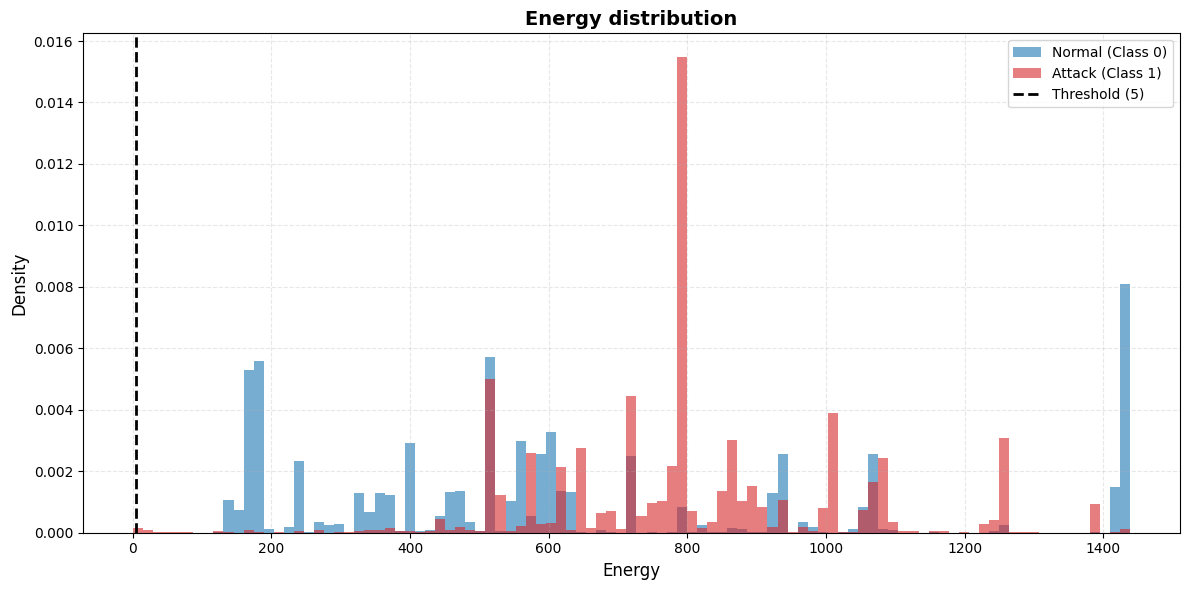


Confusion Matrix:
[[     1 443212]
 [    27  34815]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.04      0.00      0.00    443213
         1.0       0.07      1.00      0.14     34842

    accuracy                           0.07    478055
   macro avg       0.05      0.50      0.07    478055
weighted avg       0.04      0.07      0.01    478055



(array([919.23865, 627.47504, 511.5883 , ..., 402.82675, 172.77344,
        194.83212], shape=(478055,), dtype=float32),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(478055,), dtype=float32))

In [ ]:
from utils.train_utils import  evaluate_pcn_anomaly
from PCN.PCNetwork import PredictiveCodingNetwork
device = 'mps'

pcn_loaded = PredictiveCodingNetwork([41, 512, 256, 128, 64, 32])
state_dict = torch.load('pcn_model_weights_2.pth', map_location=device)
pcn_loaded.load_state_dict(state_dict)
pcn_loaded.to(device)
X_test_tensor = torch.tensor(np.array(X_test), dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(np.array(y_test), dtype=torch.float32).view(-1, 1).to(device)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=2048, shuffle=False)
pcn_loaded.eval()

evaluate_pcn_anomaly(pcn_loaded, test_loader, T_infer=T_infer, eta_infer=0.01, threshold_energy=5, device=device)